# Phân tích Khám phá Tuyển sinh Đại học Việt Nam (EDA)
## Notebook 01: Tổng quan Dữ liệu & Thống kê Mô tả

Notebook này thực hiện:
1. Đọc và kiểm tra cấu trúc dữ liệu đã được xử lý (Processed Data).
2. Thống kê mô tả các biến số cơ bản.
3. Phân tích phân bố điểm chuẩn và kiểm tra dữ liệu khuyết thiếu.
4. Phân tích mức độ cạnh tranh tuyển sinh.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình font tiếng Việt và giao diện biểu đồ
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/processed/admission_processed.csv"
assert os.path.exists(DATA_PATH), "Vui lòng chạy ETL pipeline trước để tạo file admission_processed.csv!"

### 1. Nạp và kiểm tra dữ liệu

In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng, {df.shape[1]} cột")
df.head()

Kích thước dữ liệu: 187,674 dòng, 18 cột


,school_code,school_name,major_code,major_name,subject_group,admission_score,quota,admission_method,year,source_url,crawled_at,major_group,competition_level,delta_score,delta_score_pct,score_trend,avg_score_school,rank_in_year
0,ANH,ANH-Học Viện An Ninh Nhân Dân,NaN,Ngành An ninh mạng và phòng chống tội phạm côn...,A00,24.54,100,Xét điểm thi THPT,2020,https://diemthi.tuyensinh247.com/diem-chuan/ho...,2026-06-29 16:55:06,Kỹ thuật - Công nghệ,Cao,NaN,NaN,Không xác định,23.46,5767
1,ANH,ANH-Học Viện An Ninh Nhân Dân,NaN,Ngành An ninh mạng và phòng chống tội phạm côn...,A00,25.08,100,Xét điểm thi THPT,2021,https://diemthi.tuyensinh247.com/diem-chuan/ho...,2026-06-29 16:55:06,Kỹ thuật - Công nghệ,Rất cao,0.54,2.20,Tăng,23.92,5691
2,ANH,ANH-Học Viện An Ninh Nhân Dân,NaN,Ngành An ninh mạng và phòng chống tội phạm côn...,A00,23.95,100,Xét điểm thi THPT,2022,https://diemthi.tuyensinh247.com/diem-chuan/ho...,2026-06-29 16:55:06,Kỹ thuật - Công nghệ,Cao,-1.13,-4.51,Giảm,22.82,5578
3,ANH,ANH-Học Viện An Ninh Nhân Dân,NaN,Ngành An ninh mạng và phòng chống tội phạm côn...,A00,24.28,100,Xét điểm thi THPT,2023,https://diemthi.tuyensinh247.com/diem-chuan/ho...,2026-06-29 16:55:06,Kỹ thuật - Công nghệ,Cao,0.33,1.38,Ổn định,23.08,5523
4,ANH,ANH-Học Viện An Ninh Nhân Dân,NaN,Ngành An ninh mạng và phòng chống tội phạm côn...,A00,24.30,100,Xét điểm thi THPT,2024,https://diemthi.tuyensinh247.com/diem-chuan/ho...,2026-06-29 16:55:06,Kỹ thuật - Công nghệ,Cao,0.02,0.08,Ổn định,23.28,5853


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187674 entries, 0 to 187673
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   school_code        187674 non-null  str    
 1   school_name        187674 non-null  str    
 2   major_code         0 non-null       float64
 3   major_name         187674 non-null  str    
 4   subject_group      187674 non-null  str    
 5   admission_score    187674 non-null  float64
 6   quota              187674 non-null  int64  
 7   admission_method   187674 non-null  str    
 8   year               187674 non-null  int64  
 9   source_url         187674 non-null  str    
 10  crawled_at         187674 non-null  str    
 11  major_group        187674 non-null  str    
 12  competition_level  187674 non-null  str    
 13  delta_score        156395 non-null  float64
 14  delta_score_pct    156395 non-null  float64
 15  score_trend        187674 non-null  str    
 16  avg_score_sch

### 2. Thống kê mô tả số lượng trường, ngành, tổ hợp qua các năm

In [4]:
summary_by_year = df.groupby('year').agg(
    num_records=('school_name', 'count'),
    num_schools=('school_name', 'nunique'),
    num_majors=('major_name', 'nunique'),
    num_groups=('subject_group', 'nunique'),
    avg_score=('admission_score', 'mean'),
    total_quota=('quota', 'sum')
).reset_index()
summary_by_year.round(2)

,year,num_records,num_schools,num_majors,num_groups,avg_score,total_quota
0,2020,31279,271,2290,133,19.86,3127900
1,2021,31279,271,2290,133,20.33,3127900
2,2022,31279,271,2290,133,19.35,3127900
3,2023,31279,271,2290,133,19.55,3127900
4,2024,31279,271,2290,133,19.70,3127900
5,2025,31279,271,2290,133,19.69,3127900


### 3. Phân tích phân bố điểm chuẩn tuyển sinh

In [5]:
df['admission_score'].describe()

count    187674.000000
mean         19.746681
std           4.246419
min          13.000000
25%          15.340000
50%          19.310000
75%          23.450000
max          30.000000
Name: admission_score, dtype: float64

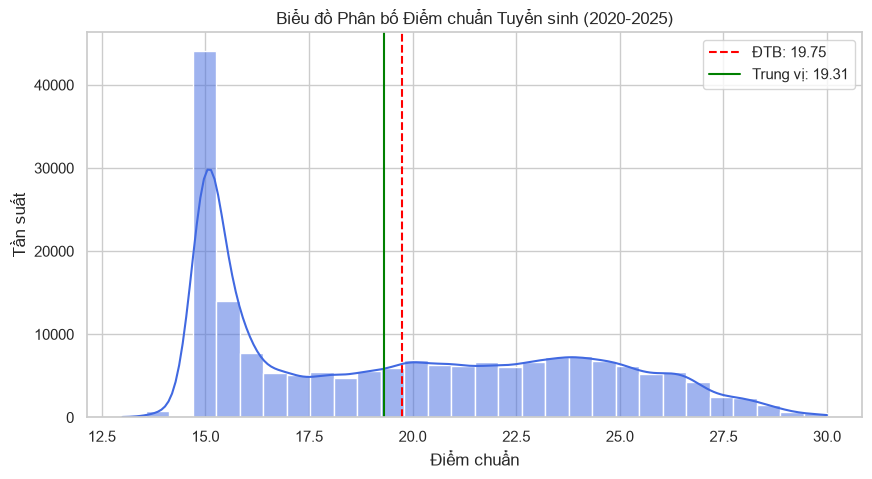

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['admission_score'], kde=True, bins=30, color='royalblue')
plt.title('Biểu đồ Phân bố Điểm chuẩn Tuyển sinh (2020-2025)')
plt.xlabel('Điểm chuẩn')
plt.ylabel('Tần suất')
plt.axvline(df['admission_score'].mean(), color='red', linestyle='--', label=f"ĐTB: {df['admission_score'].mean():.2f}")
plt.axvline(df['admission_score'].median(), color='green', linestyle='-', label=f"Trung vị: {df['admission_score'].median():.2f}")
plt.legend()
plt.show()

### 4. Phân tích mức độ cạnh tranh tuyển sinh

In [7]:
competition_counts = df['competition_level'].value_counts(dropna=False)
print(competition_counts)

competition_level
Thấp          81050
Trung bình    42671
Cao           36471
Rất cao       27482
Name: count, dtype: int64


/tmp/ipykernel_57432/1884097279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='competition_level', data=df, order=['Rất cao', 'Cao', 'Trung bình', 'Thấp'], palette='viridis')


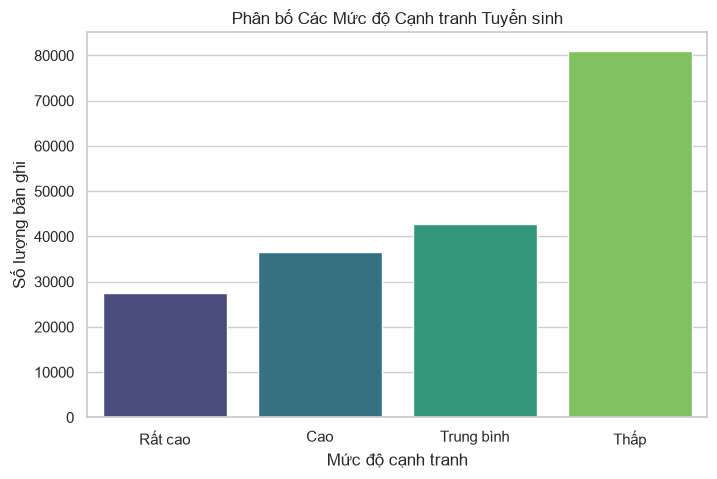

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='competition_level', data=df, order=['Rất cao', 'Cao', 'Trung bình', 'Thấp'], palette='viridis')
plt.title('Phân bố Các Mức độ Cạnh tranh Tuyển sinh')
plt.xlabel('Mức độ cạnh tranh')
plt.ylabel('Số lượng bản ghi')
plt.show()